In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.linear_model import LinearRegression
from sklearn import metrics
df=pd.read_csv('https://github.com/Explore-AI/Public-Data/blob/master/exports%20ZAR-USD-data.csv?raw=true', index_col=0)
df.columns=['Y','X']
df.head()

,Y,X
2008M01,7.01,39356.82
2008M02,7.66,46946.33
2008M03,7.97,51150.89
2008M04,7.79,56174.34
2008M05,7.62,56240.45


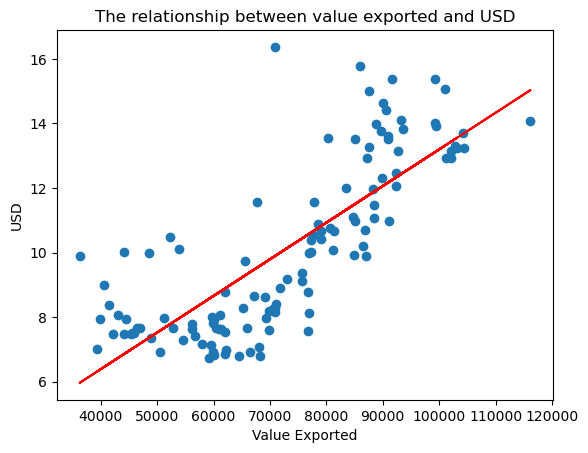

In [2]:
X=df.X.values
Y=df.Y.values

x_bar=np.mean(X)
y_bar=np.mean(Y)

m= sum((X-x_bar)*(Y-y_bar))/sum((X-x_bar)**2)
c= y_bar - m*x_bar

def gen_y(x_gen, m, c):
    y_gen=[]
    for x_i in x_gen:
        y_i=x_i*m +c
        y_gen.append(y_i)
    return y_gen

y_gen = df.X*m +c

plt.scatter(df.X, df.Y)
plt.plot(df.X, y_gen, color='red')
plt.title('The relationship between value exported and USD')
plt.xlabel('Value Exported')
plt.ylabel('USD')
plt.show()


In [3]:
print('slope:', m)
print('intercept:',c)

slope: 0.000113507257658843
intercept: 1.8448114670426463


In [6]:
errors2=np.array(y_gen - df.Y)
print(np.round(errors2,2))

[-0.7  -0.49 -0.32  0.43  0.61  0.75  1.17  1.04  0.72 -0.44 -2.14 -2.62
 -3.94 -3.16 -2.69 -2.54 -1.83 -1.32 -1.06 -1.57 -0.51 -0.63 -0.47 -0.49
 -0.82 -0.55  0.87  0.04  0.19  1.14  1.36  0.74  1.47  1.74  1.93  1.82
  0.67  1.25  2.47  1.82  2.01  2.8   2.37  2.5   2.99  1.75  2.46  1.58
  0.62  1.66  2.15  0.82  1.75  1.53  1.59  1.61  0.98  1.06  1.77  0.83
  0.09  1.1   0.93  1.32  1.06  0.58  1.82  0.96  0.59  1.57  1.47  0.23
 -0.12  0.51  0.24  0.1   0.41  0.4   1.01  0.15  1.2   0.8   0.36  0.42
 -2.04 -0.9   0.25 -0.68 -0.11 -0.26 -0.13 -1.19 -1.44 -2.02 -1.69 -3.21
 -6.47 -4.16 -3.14 -2.56 -2.27 -1.77 -2.27 -1.73 -0.91 -2.05 -0.78 -1.38
 -2.59 -1.49  0.39 -1.33  0.21  0.51 -0.76  0.33  0.28 -0.04  0.97  0.44]


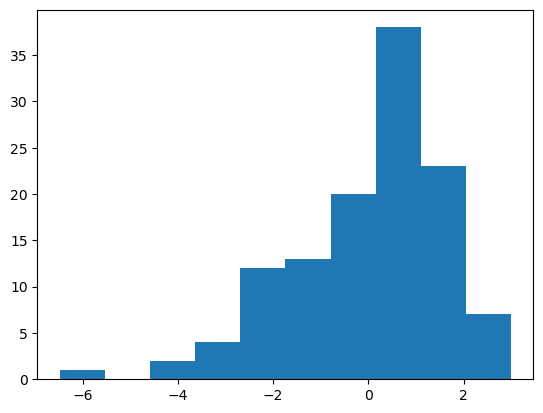

In [7]:
plt.hist(errors2)
plt.show()

In [8]:
print('The residual sum of square:',np.sum(errors2**2))

The residual sum of square: 321.45716655257655


In [9]:
lm=LinearRegression()

In [10]:
X=df.X.values[:,np.newaxis]

In [11]:
lm.fit(X,df.Y)

LinearRegression()

In [12]:
m=lm.coef_[0]
c=lm.intercept_

In [13]:
y_gen=m*X +c

In [14]:
print("Slope:\t\t", m)
print("Intercept:\t", c)

Slope:		 0.00011350725765884303
Intercept:	 1.8448114670426445


In [15]:
gen_y=lm.predict(X)

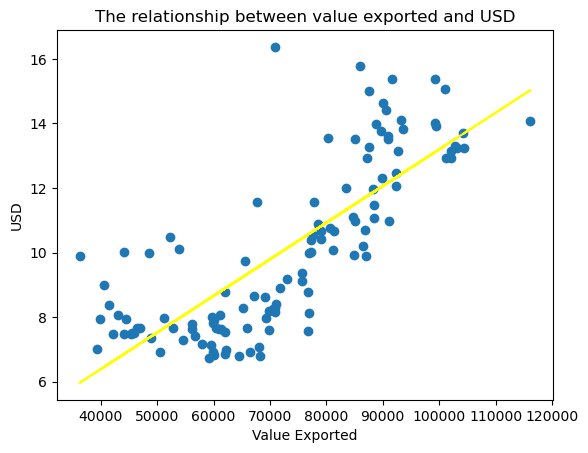

In [17]:
plt.scatter(df.X, df.Y)
plt.plot(X, gen_y, color='yellow')
plt.title('The relationship between value exported and USD')
plt.xlabel('Value Exported')
plt.ylabel('USD')
plt.show()


In [25]:
print('MSE:', metrics.mean_squared_error(df.Y,gen_y))
print('RSS:', metrics.mean_squared_error(df.Y, gen_y)*len(X))
print('R2:',round((metrics.r2_score(df.Y,gen_y)*100),2),'%')

MSE: 2.678809721271471
RSS: 321.45716655257655
R2: 61.58 %
